# Hotel Business Analysis using Python

## Project Overview

This project analyzes hotel booking data to understand customer behavior, booking trends, cancellation patterns, pricing strategies, and market performance. It also builds a Machine Learning model to predict booking cancellations and provides business recommendations based on the analysis.

# Project Objective

The main objectives of this project are:

- Analyze hotel booking patterns.
- Identify factors affecting booking cancellations.
- Study seasonal booking trends.
- Understand customer behavior and preferences.
- Build a Machine Learning model to predict booking cancellations.
- Generate business insights and recommendations for hotel management.

# Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook / VS Code

# Project Workflow

1. Import Libraries
2. Load Dataset
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Data Visualization
6. Feature Engineering
7. Machine Learning Model
8. Model Evaluation
9. Feature Importance
10. Business Insights
11. Conclusion

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

In [7]:
# Load Dataset
df = pd.read_csv("data/hotel_bookings_data.csv")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.head()

Rows: 119,390
Columns: 29


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,...,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
0,Resort Hotel,0,342,2017,September,27,1,0,0,2,...,3,No Deposit,NaN,NaN,0,Personal,0.0,0,0,Check-Out
1,Resort Hotel,0,737,2017,September,27,1,0,0,2,...,4,No Deposit,NaN,NaN,0,Personal,0.0,0,0,Check-Out
2,Resort Hotel,0,7,2017,September,27,1,0,1,1,...,0,No Deposit,NaN,NaN,0,Personal,75.0,0,0,Check-Out
3,Resort Hotel,0,13,2017,September,27,1,0,1,1,...,0,No Deposit,304.0,NaN,0,Personal,75.0,0,0,Check-Out
4,Resort Hotel,0,14,2017,September,27,1,0,2,2,...,0,No Deposit,240.0,NaN,0,Personal,98.0,0,1,Check-Out


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_weekdays_nights        119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [9]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2018.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2018.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2018.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2019.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2019.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [10]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_weekdays_nights               0
adults                                 0
children                               4
babies                                 0
meal                                   0
city                                 488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
booking_changes                        0
deposit_type                           0
agent                              16340
company                           112593
days_in_waiting_list                   0
customer_type   

In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 33261


In [12]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_weekdays_nights', 'adults', 'children', 'babies', 'meal',
       'city', 'market_segment', 'distribution_channel', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'deposit_type', 'agent', 'company',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status'],
      dtype='object')

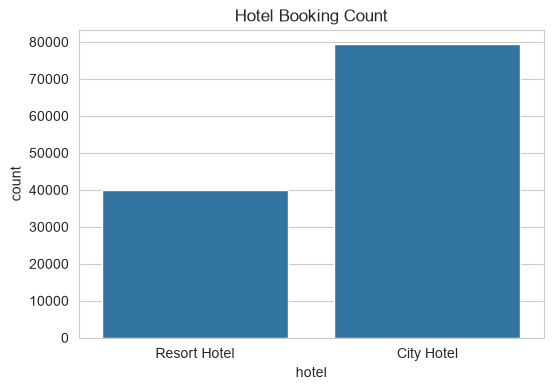

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='hotel')
plt.title("Hotel Booking Count")
plt.show()

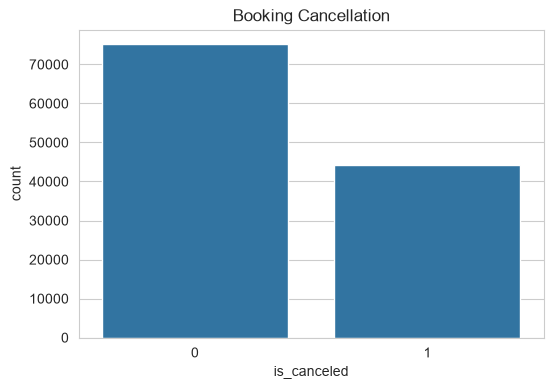

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='is_canceled')
plt.title("Booking Cancellation")
plt.show()

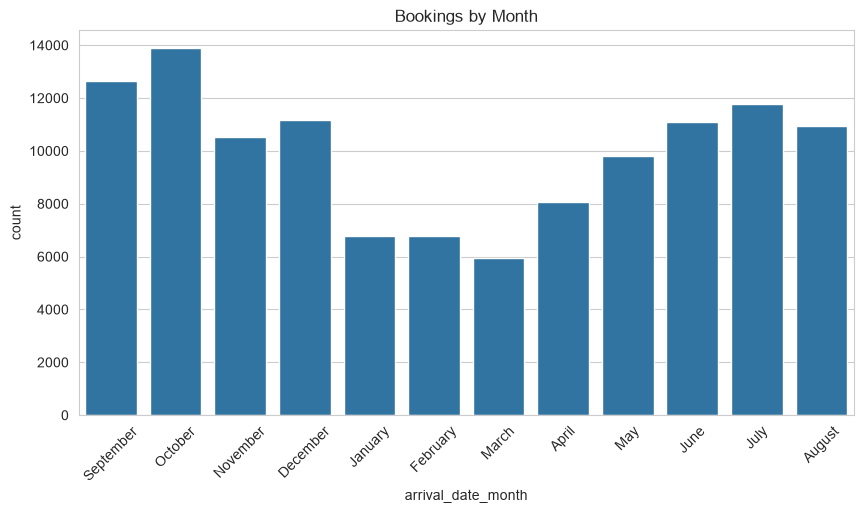

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='arrival_date_month')
plt.xticks(rotation=45)
plt.title("Bookings by Month")
plt.show()

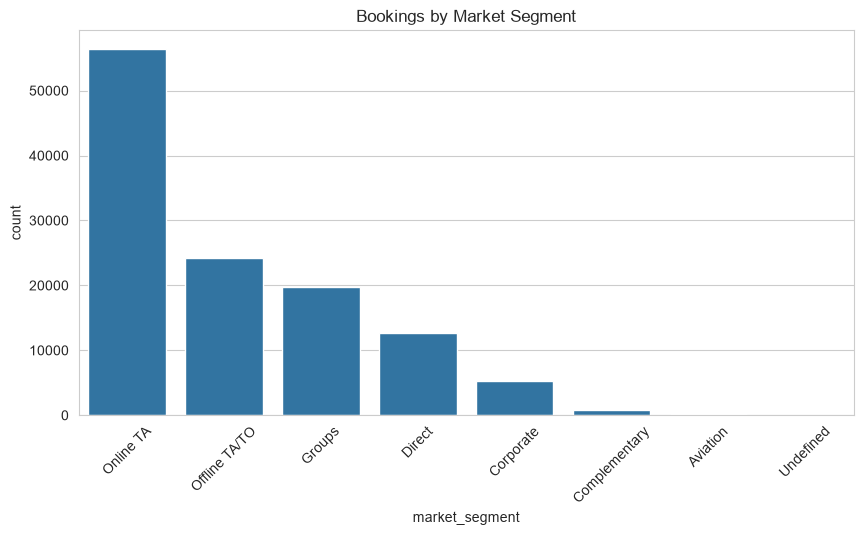

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='market_segment', order=df['market_segment'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Bookings by Market Segment")
plt.show()

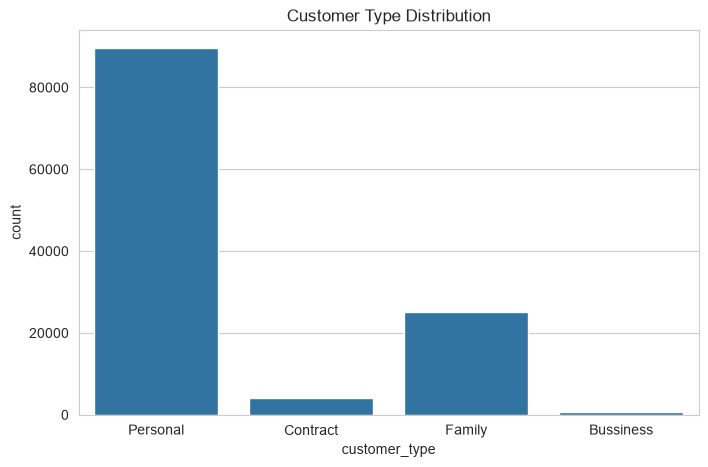

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='customer_type')
plt.title("Customer Type Distribution")
plt.show()

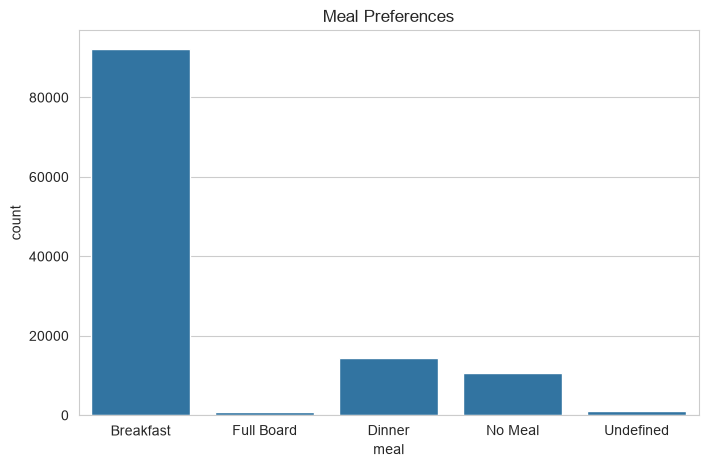

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='meal')
plt.title("Meal Preferences")
plt.show()

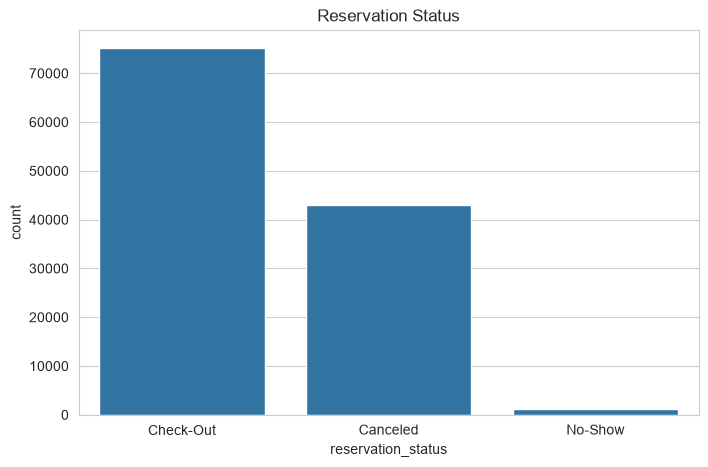

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='reservation_status')
plt.title("Reservation Status")
plt.show()

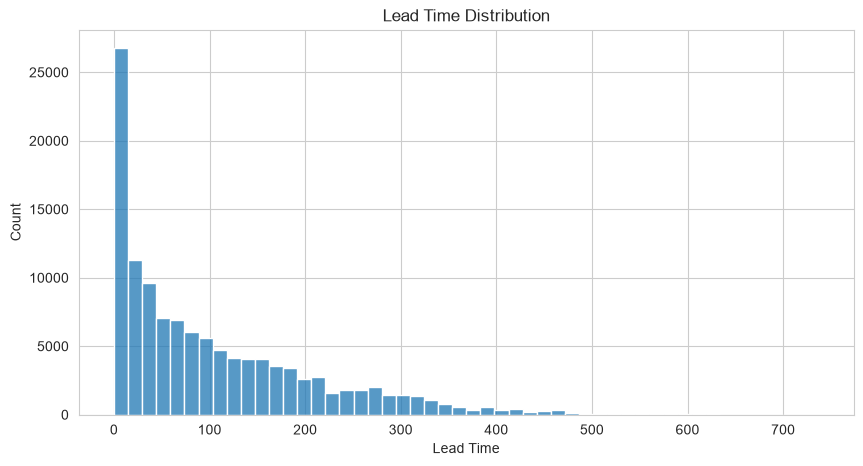

In [20]:
plt.figure(figsize=(10,5))
sns.histplot(df['lead_time'], bins=50)
plt.title("Lead Time Distribution")
plt.xlabel("Lead Time")
plt.show()

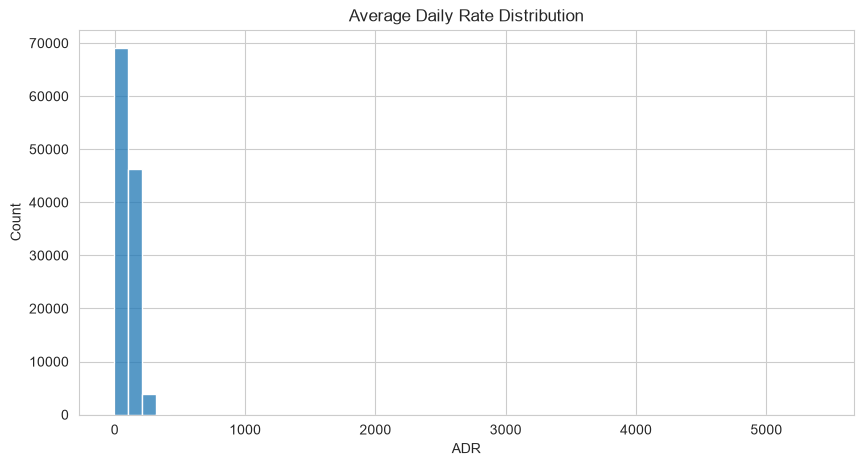

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(df['adr'], bins=50)
plt.title("Average Daily Rate Distribution")
plt.xlabel("ADR")
plt.show()

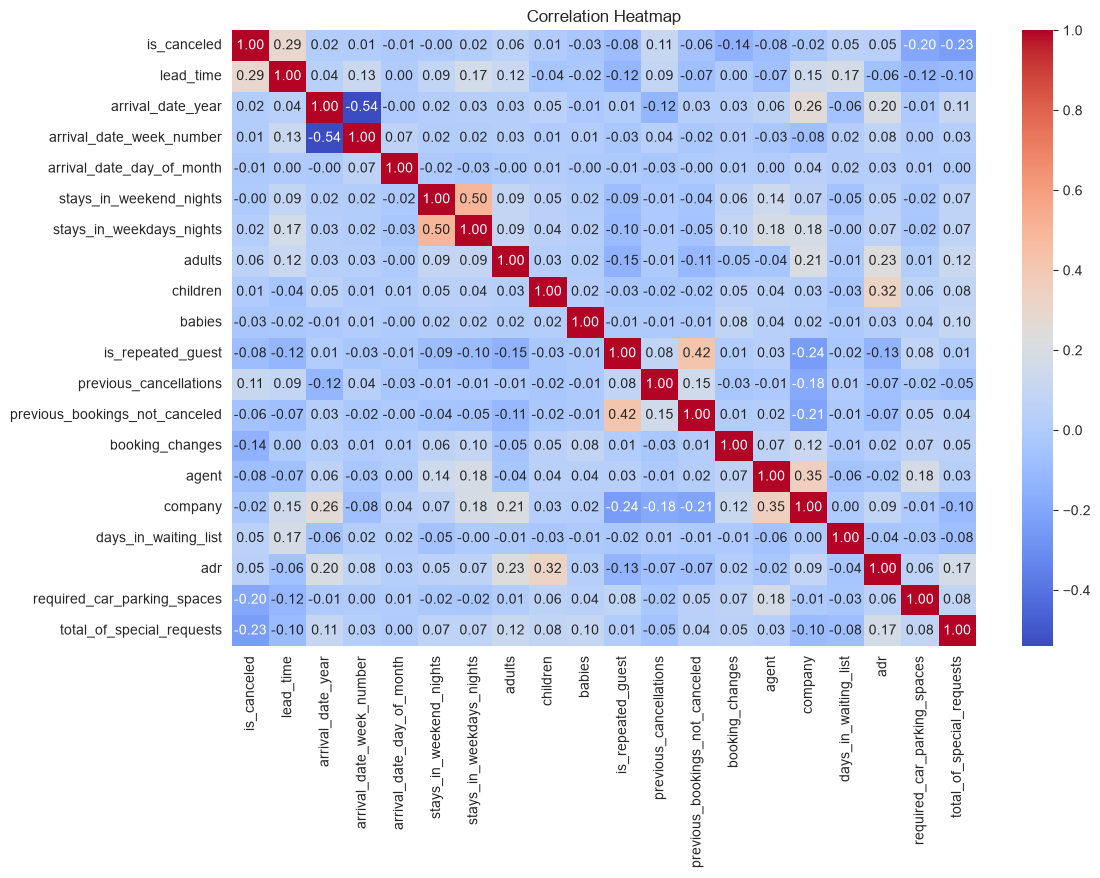

In [22]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

In [23]:
import seaborn as sns
print(sns.__version__)

0.13.2


In [24]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_weekdays_nights', 'adults', 'children', 'babies', 'meal', 'city', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status']


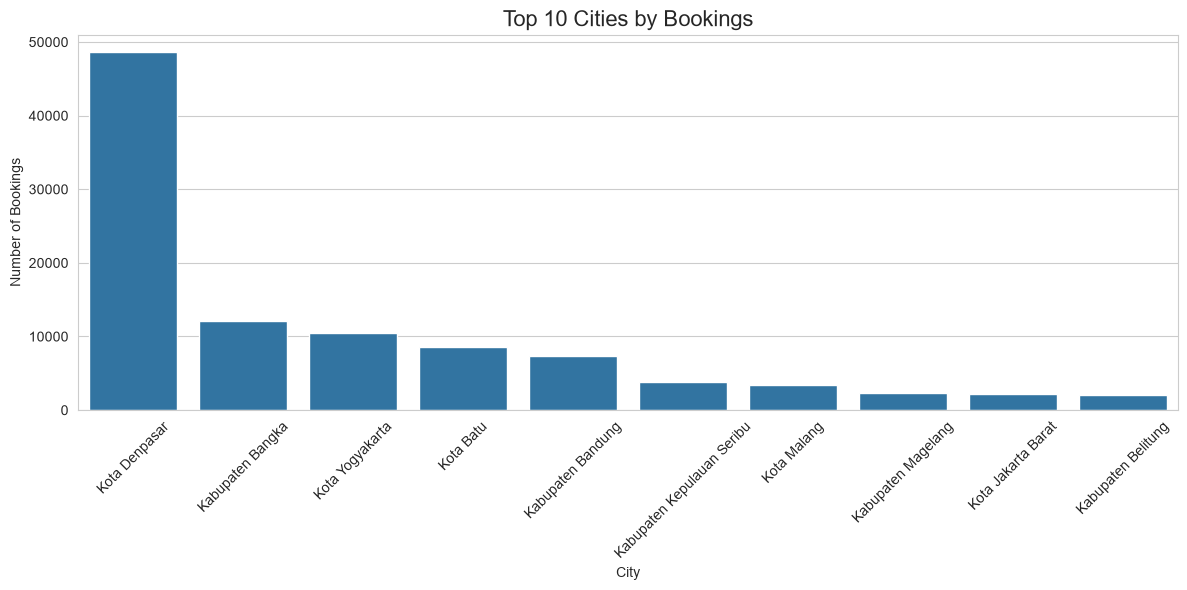

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

top10 = df['city'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top10.index,
    y=top10.values
)

plt.title("Top 10 Cities by Bookings", fontsize=16)
plt.xlabel("City")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

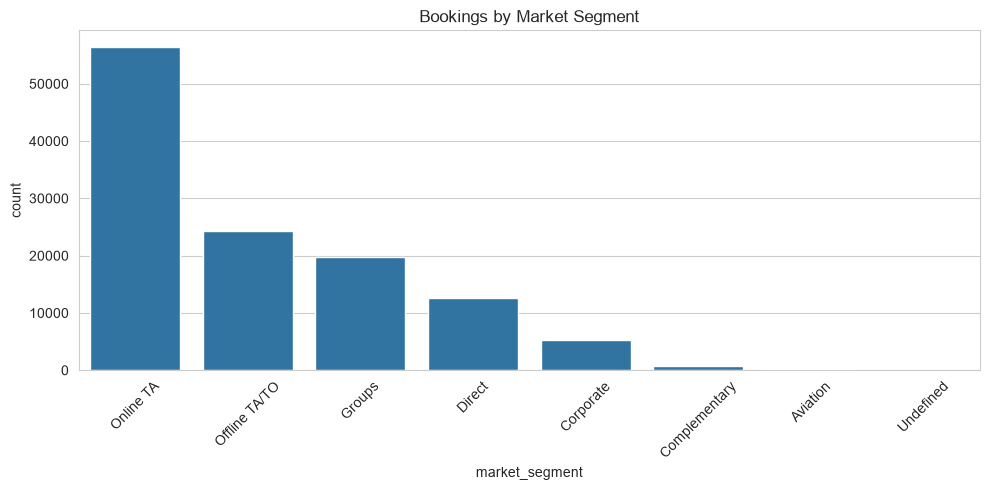

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x='market_segment',
    order=df['market_segment'].value_counts().index
)
plt.xticks(rotation=45)
plt.title("Bookings by Market Segment")
plt.tight_layout()
plt.show()

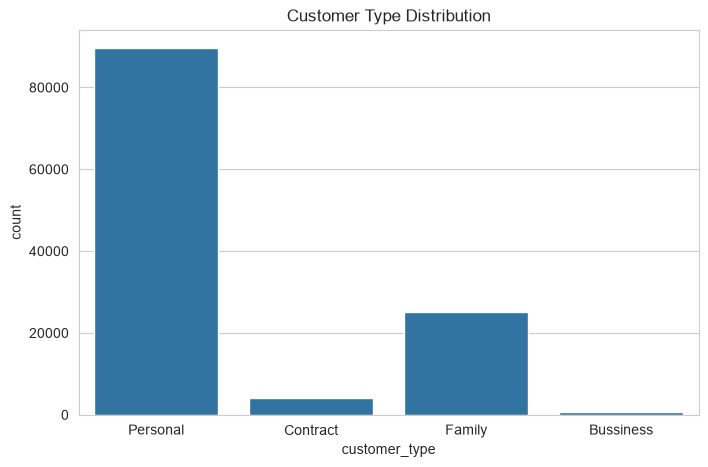

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='customer_type')
plt.title("Customer Type Distribution")
plt.show()

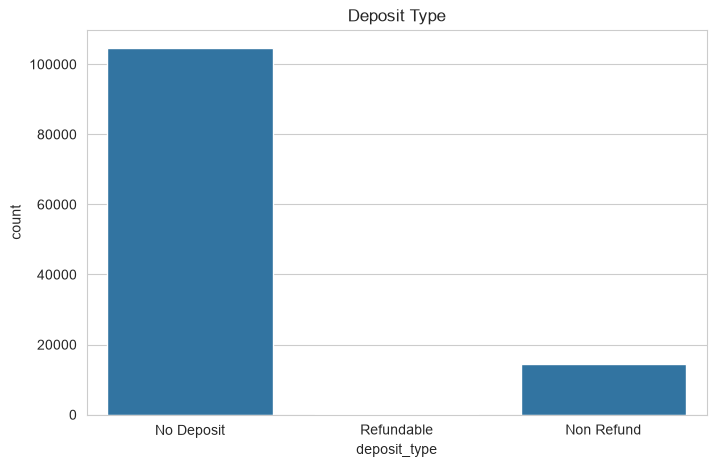

In [28]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='deposit_type')
plt.title("Deposit Type")
plt.show()

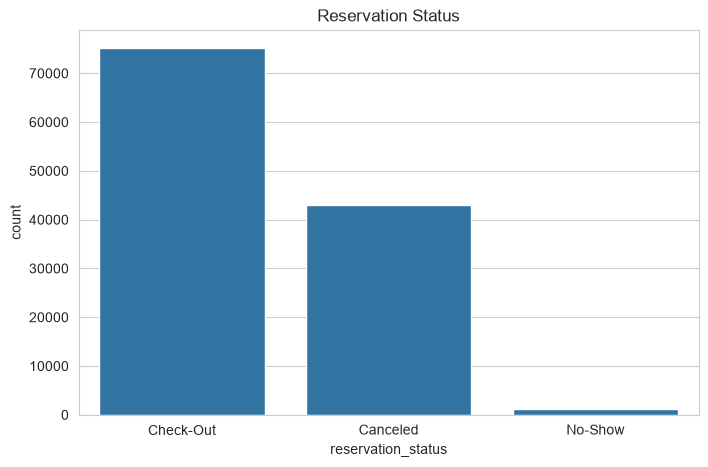

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='reservation_status')
plt.title("Reservation Status")
plt.show()

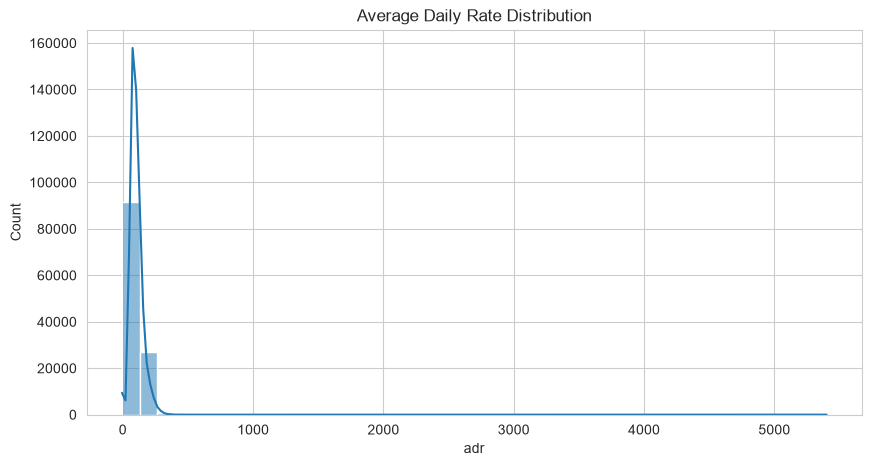

In [30]:
plt.figure(figsize=(10,5))
sns.histplot(df['adr'], bins=40, kde=True)
plt.title("Average Daily Rate Distribution")
plt.show()

In [31]:
print(df['adr'].describe())
print(df['adr'].max())

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64
5400.0


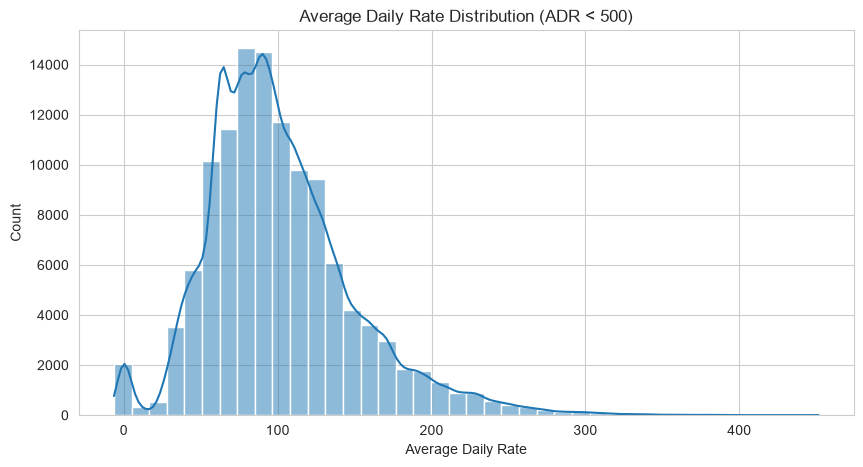

In [32]:
plt.figure(figsize=(10,5))

sns.histplot(
    df[df['adr'] < 500]['adr'],
    bins=40,
    kde=True
)

plt.title("Average Daily Rate Distribution (ADR < 500)")
plt.xlabel("Average Daily Rate")
plt.ylabel("Count")

plt.show()

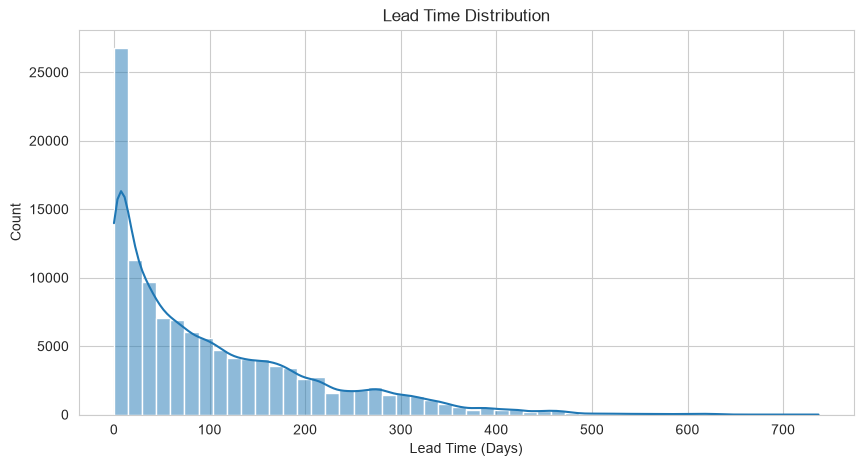

In [33]:
plt.figure(figsize=(10,5))

sns.histplot(df['lead_time'], bins=50, kde=True)

plt.title("Lead Time Distribution")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Count")

plt.show()

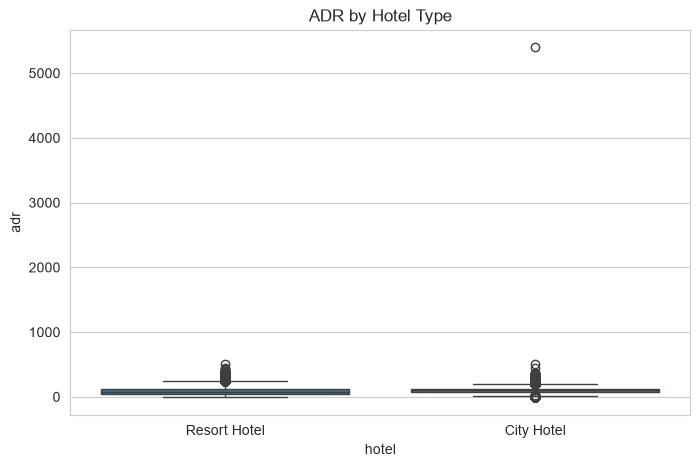

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='hotel', y='adr')

plt.title("ADR by Hotel Type")

plt.show()

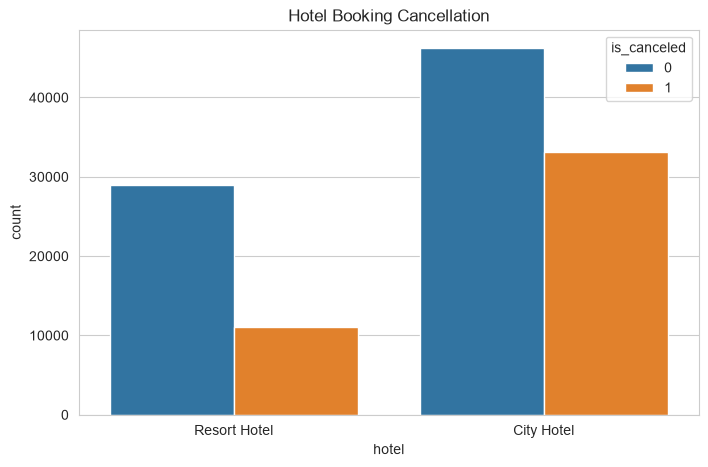

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='hotel', hue='is_canceled')

plt.title("Hotel Booking Cancellation")

plt.show()

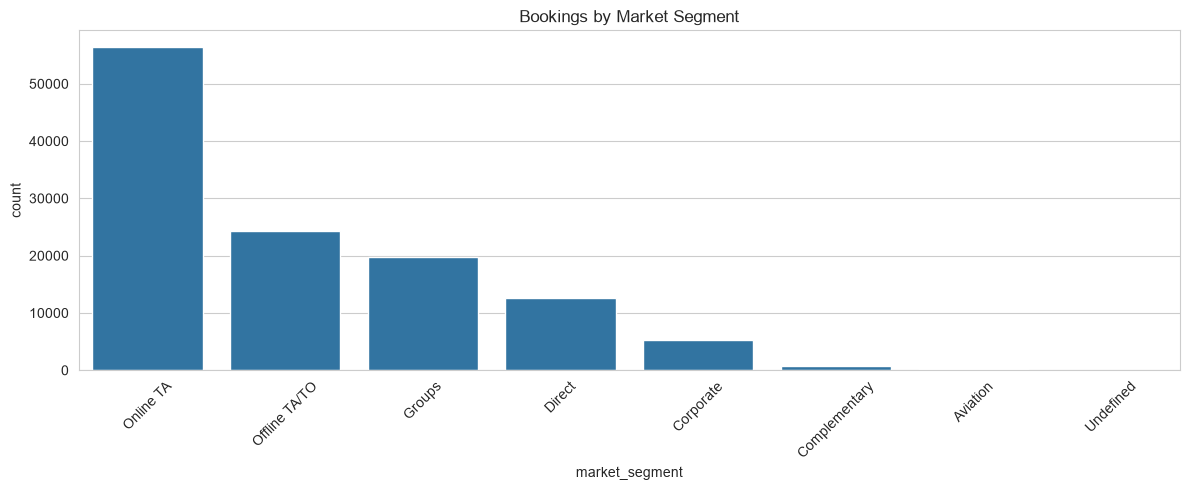

In [36]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='market_segment',
    order=df['market_segment'].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Bookings by Market Segment")

plt.tight_layout()
plt.show()

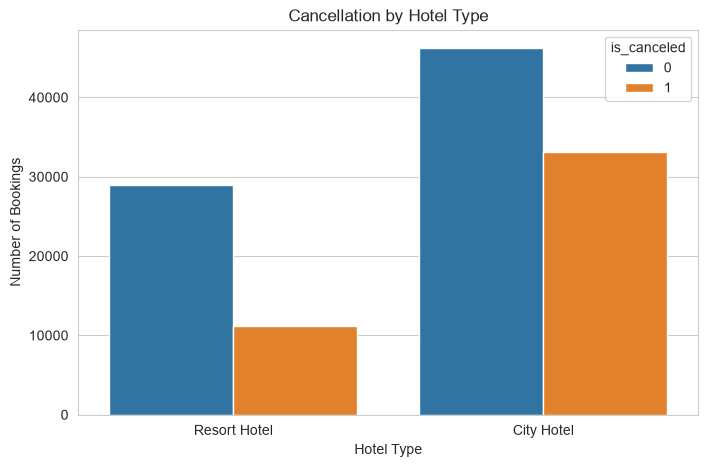

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='hotel',
    hue='is_canceled'
)

plt.title("Cancellation by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")

plt.show()

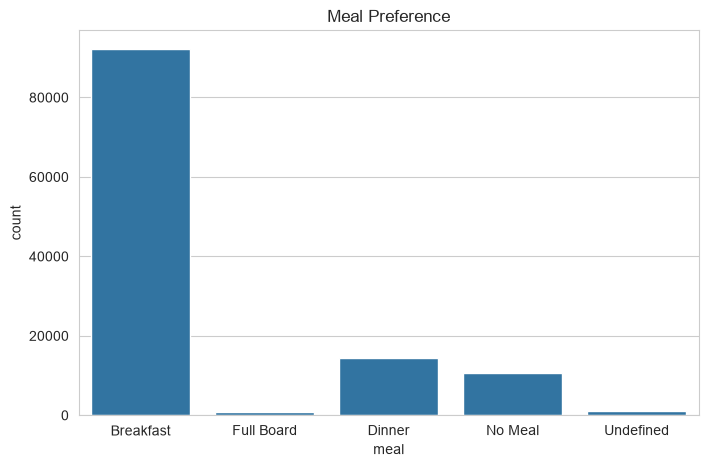

In [38]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='meal'
)

plt.title("Meal Preference")

plt.show()

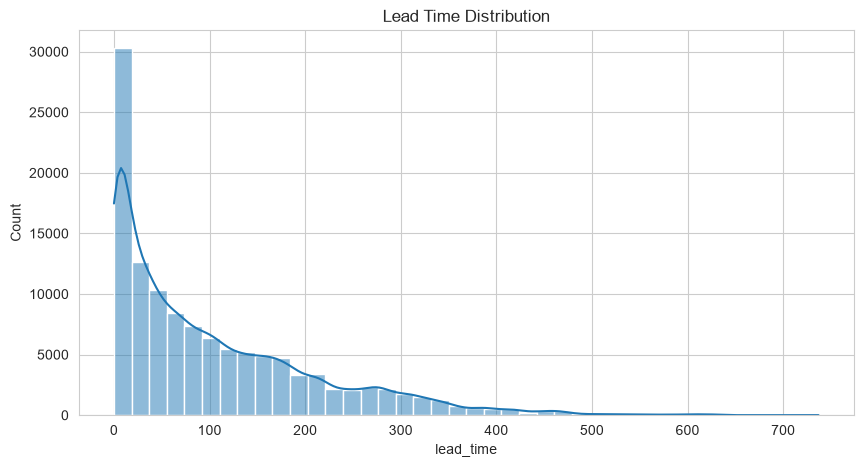

In [39]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['lead_time'],
    bins=40,
    kde=True
)

plt.title("Lead Time Distribution")

plt.show()

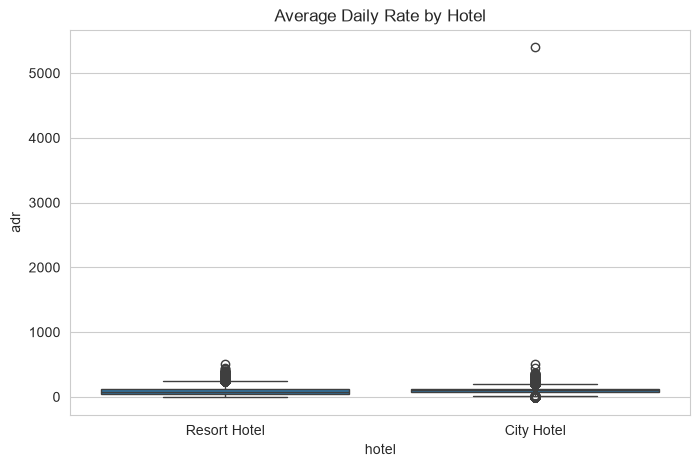

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='hotel',
    y='adr'
)

plt.title("Average Daily Rate by Hotel")

plt.show()

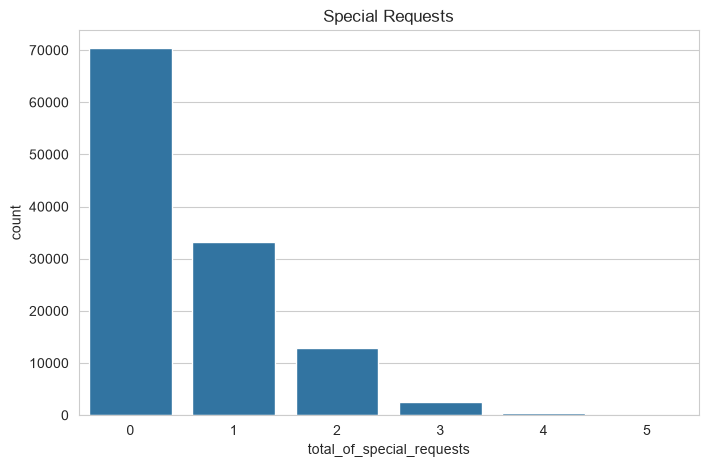

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='total_of_special_requests'
)

plt.title("Special Requests")

plt.show()

In [42]:
# Remove unnecessary columns
df_ml = df.copy()

df_ml = df_ml.drop(['reservation_status'], axis=1)

# Convert categorical columns into numbers
df_ml = pd.get_dummies(df_ml, drop_first=True)

df_ml.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,children,babies,...,market_segment_Undefined,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Contract,customer_type_Family,customer_type_Personal
0,0,342,2017,27,1,0,0,2,0.0,0,...,False,True,False,False,False,False,False,False,False,True
1,0,737,2017,27,1,0,0,2,0.0,0,...,False,True,False,False,False,False,False,False,False,True
2,0,7,2017,27,1,0,1,1,0.0,0,...,False,True,False,False,False,False,False,False,False,True
3,0,13,2017,27,1,0,1,1,0.0,0,...,False,False,False,False,False,False,False,False,False,True
4,0,14,2017,27,1,0,2,2,0.0,0,...,False,False,False,True,False,False,False,False,False,True


In [43]:
from sklearn.model_selection import train_test_split

X = df_ml.drop('is_canceled', axis=1)
y = df_ml['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [45]:
y_pred = model.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8971438143898149


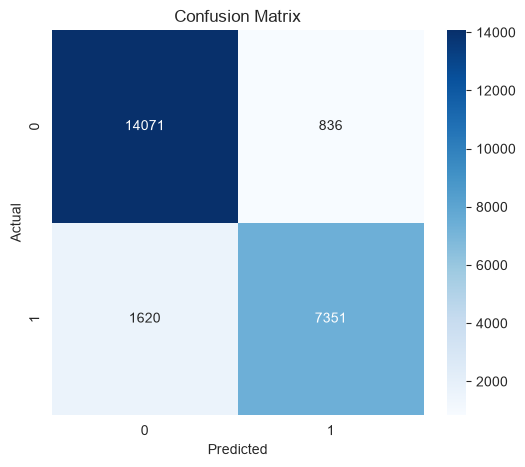

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92     14907
           1       0.90      0.82      0.86      8971

    accuracy                           0.90     23878
   macro avg       0.90      0.88      0.89     23878
weighted avg       0.90      0.90      0.90     23878



In [49]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

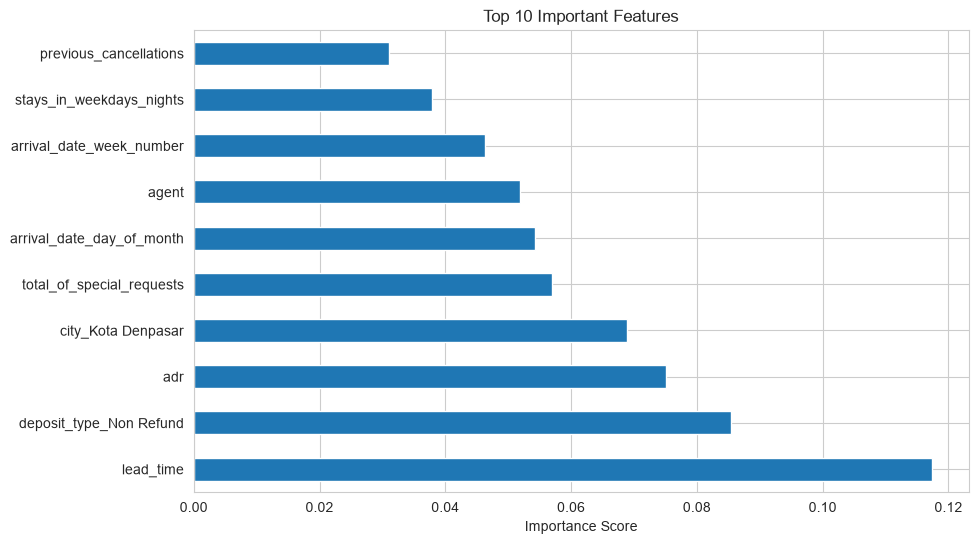

In [50]:
plt.figure(figsize=(10,6))

importance.head(10).plot(
    kind='barh'
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")

plt.show()

# Machine Learning Conclusion

A Random Forest Classifier was trained to predict whether a hotel booking would be cancelled.

The model was evaluated using accuracy, a confusion matrix, and a classification report. Feature importance analysis identified the variables that most strongly influenced booking cancellation predictions.

This predictive model can help hotel managers identify high-risk bookings, improve cancellation management, and make better operational decisions.

# Final Conclusion

This project analyzed hotel booking data using Python to identify booking trends, customer behavior, cancellation patterns, and key factors affecting hotel operations. Exploratory Data Analysis (EDA) and a Random Forest machine learning model provided valuable insights that can help improve pricing strategies, reduce cancellations, and support better business decisions.